/home/eltisau/software/miniconda3/envs/MG5/lib/python3.13/site-packages/awkward_pandas/array.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(ak.is_none(self._data))
/home/eltisau/software/miniconda3/envs/MG5/lib/python3.13/site-packages/awkward_pandas/array.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(ak.is_none(self._data))


File=Hexagonal_15mm_LSO_127MeV_100k.root
o-Ps, detection efficiency= 0.12538


/home/eltisau/software/miniconda3/envs/MG5/lib/python3.13/site-packages/awkward_pandas/array.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(ak.is_none(self._data))
/home/eltisau/software/miniconda3/envs/MG5/lib/python3.13/site-packages/awkward_pandas/array.py:120: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(ak.is_none(self._data))


File=Squarecoordinates_127MeV_thickness5.root
o-Ps, detection efficiency= 0.05545


Text(0, 1, 'efficiency')

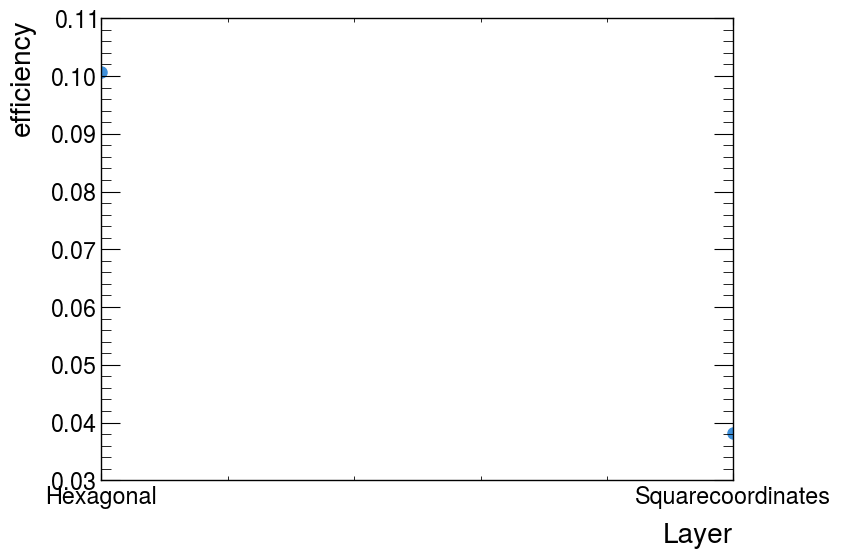

In [ ]:

import uproot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor

import mplhep as mpl

mpl.style.use('ATLAS')

files=["Hexagonal_15mm_LSO_127MeV_100k.root","Squarecoordinates_127MeV_thickness5.root"]
efficiencys=[]
for file_ in files:
    # Load the original ROOT file
    with uproot.open(file_) as file:
        # Extract relevant NTuples
        edep_tree = file["EdepCounter"]
        truth_gamma_tree = file["TruthGamma"]
        truth_ps_tree = file["TruthPs"]
        truth_positron_tree = file["TruthPositron"]
        # Convert to DataFrames (multi-thread if large, but for simplicity sequential)
        edep_df = edep_tree.arrays(library="pd")
        truth_gamma_df = truth_gamma_tree.arrays(library="pd")
        truth_ps_df = truth_ps_tree.arrays(library="pd")
        truth_positron_df = truth_positron_tree.arrays(library="pd")

    # Process TruthGamma to split into oPs, pPs, others
    # Get o-Ps and p-Ps TrackIDs from TruthPs
    o_ps_ids = truth_ps_df[truth_ps_df['Type'] == 'o-Ps']['TrackID'].unique()
    p_ps_ids = truth_ps_df[truth_ps_df['Type'] == 'p-Ps']['TrackID'].unique()

    # Filter TruthGamma
    truth_gamma_ops_df = truth_gamma_df[truth_gamma_df['ParentID'].isin(o_ps_ids)]
    truth_gamma_pps_df = truth_gamma_df[truth_gamma_df['ParentID'].isin(p_ps_ids)]
    truth_gamma_others_df = truth_gamma_df[~(truth_gamma_df['ParentID'].isin(o_ps_ids) | truth_gamma_df['ParentID'].isin(p_ps_ids))]

    # EdepCounter: Group by EventID and DetectorName, sum Edep_MeV (keep as-is if no sum needed, but assume per detector sum)
    edep_grouped = edep_df.groupby(['EventID', 'DetectorName','FirstTime_ns'])['Edep_MeV'].sum().reset_index()
    new_file=pd.DataFrame()
    # Write to new ROOT file
    edep_df = pd.DataFrame({
        "EventID": edep_grouped['EventID'].values,
        "DetectorName": edep_grouped['DetectorName'].values,
        "Edep_MeV": edep_grouped['Edep_MeV'].values,
        "FirstTime_ns": edep_grouped['FirstTime_ns'].values
    })
    common_events=edep_df.groupby("EventID").filter(lambda x:len(x)==1)
    common_events['Max_Edep']=common_events.groupby('EventID')['Edep_MeV'].transform('max')
    common_events['Total_Edep']=common_events.groupby('EventID')['Edep_MeV'].transform('sum')
    common_events["Remaining_Sum"]=common_events['Total_Edep']-common_events['Max_Edep']
    print("File=%s"%(file_))
    print("o-Ps, detection efficiency=",common_events["Total_Edep"].between(0.6,1.3).sum()/100000)
    efficiencys.append(common_events["Total_Edep"].between(1,1.3).sum()/100000)


filenames=[]
for file in files:
    filename=file.split("_")[0]
    filenames.append(filename)
plt.plot(filenames,efficiencys,"o")
plt.xlabel("Layer")
plt.ylabel("efficiency")